<a href="https://colab.research.google.com/github/lawanmuk/hbn-parabolic-two-band-model/blob/main/Copy_of_Analysis_of_TBModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of the parabolic two band model to investigate the Dynamical Franz-Keldeysh Effect (DFKE) adapted from the Lecture notes of Shunsuke Sato.


#Download Data Files

In [ ]:
!pip install anonfile > /dev/null
from anonfile import AnonFile

anon = AnonFile()
filename = anon.download("https://anonfiles.com/scVet4U5ye/equilibrium_100", path='.')
filename = anon.download("https://anonfiles.com/Z9ldD1S9y3/pumpprobe_zerodelay", path='.')
filename = anon.download("https://anonfiles.com/HcXft7U7y0/1fs_delay_pp", path='.')
filename = anon.download("https://anonfiles.com/jeWct2Uayc/transient_absorption", path='.')


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
markdown 3.4.1 requires importlib-metadata>=4.4; python_version < "3.10", but you have importlib-metadata 4.0.1 which is incompatible.
gym 0.25.2 requires importlib-metadata>=4.8.0; python_version < "3.10", but you have importlib-metadata 4.0.1 which is incompatible.


In [ ]:
import sys
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.constants import e, m_e, pi, hbar
from numpy.ma import masked_array

#Input Constants

In [ ]:
h2ev = 27.21138386            # Hartree to eV
au2fs = 0.02418884254         # a.u to femtosecond
c = 137.0                     # Speed of light in a.u

#Parameters for the parabolic bands
$$
\begin{aligned}
& \epsilon_{v, \vec{k}}=-\frac{\vec{k}^{2}}{2 m_{v}}, \\
& \epsilon_{c, \vec{k}}=\epsilon_{g}+\frac{\vec{k}^{2}}{2 m_{c}},
\end{aligned}
$$

In [ ]:
mm_v = 0.5
mm_c = 0.3
k = np.linspace(-np.pi, np.pi, 10000)  # k-vectors
E_v = -k**2/ 2 * mm_v  # conduction band energy levels
E_c = (k**2/2 * mm_c) + 4.45  # valence band energy levels

#Plot of the parabolic bands.

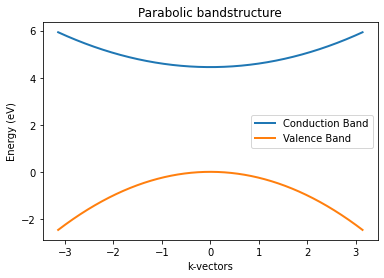

In [ ]:
# Plot the band structure
plt.plot(k, E_c, label="Conduction Band", linewidth = 2)
plt.plot(k, E_v, label="Valence Band", linewidth = 2)
plt.xlabel("k-vectors")
plt.ylabel("Energy (eV)")
plt.title('Parabolic bandstructure')
plt.legend()
plt.show()


#In 2-D, the Imaginary part of the Dielectric function is given by
$$
\Im[\epsilon(\omega)](\omega)=\left(\frac{2 \pi e}{m \omega}\right)^{2} \frac{2}{(2 \pi)^{3}} \int d \vec{k}~\left|p_{v c, \vec{k}}\right|^{2} \delta\left(\epsilon_{c, \vec{k}}-\epsilon_{v, \vec{k}}-\hbar \omega\right)
$$

#Set up Prefactors

In [ ]:
omega = np.linspace(-5, 5, 500)       #frequency in eV
e_c = 4.45                            #The energy of the conduction band electrons
e_v = 0.0                             #The energy of the valence band electrons
p_vc = 0.96                           #The inter-band transition matrix element
k_points = np.array([330, 330])       # The momentum vectors of the electrons
#im_eps = np.zeros(len(omega))

In [ ]:
prefactor = (2 * pi * e**2) / (m_e * omega) ** 2 * 2 / (2 * pi) ** 3


 # Calculate the delta function

In [ ]:
delta = e_c - e_v - omega*hbar

In [ ]:
def dielectric_function(omega, e_c, e_v, p_vc, k_points):
   integral = np.sum(np.abs(p_vc)**2 * delta[:,np.newaxis] * k_points)
   im_eps = prefactor * integral
   return im_eps

# Calculate the imaginary part of the dielectric function for each frequency

In [ ]:
im_eps = dielectric_function(omega, e_c, e_v, p_vc, k_points)


# Create a plot of the imaginary part of the dielectric function vs frequency

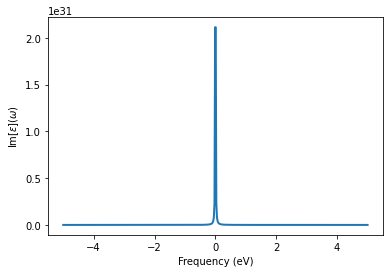

In [ ]:
plt.plot(omega, im_eps, linewidth = 2)
plt.xlabel("Frequency (eV)")
plt.ylabel("Im[$\epsilon$]($\omega$)")
plt.show()

# Load data file to extract vector potential and Current

In [ ]:
pump = np.loadtxt("equilibrium_100")              # Vector potential and Current file from pump only calculation
time = pump[:, 0]                                 # Time steps
vec_pot =pump[:, 1]                               # Pump/probe field
pump_current = pump[:, 4]                         # Current
electric_field = pump[:, 7]                       # Electric Field

# Plot of vector potential, current, electric field,

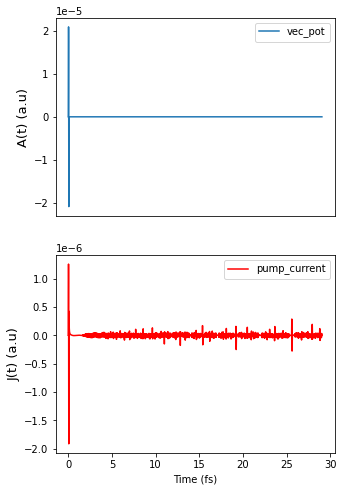

In [ ]:
fx = plt.figure()
fx.set_figwidth(5)
fx.set_figheight(8)
plt.figure(1)
plt.subplot(2,1,1)
plt.plot(time*au2fs, vec_pot, label = 'vec_pot' )
plt.ylabel(r'A(t) (a.u)', size = 13)
plt.xticks([])
plt.legend()
plt.subplot(2,1,2)
plt.plot(time*au2fs, pump_current, 'r', label = 'pump_current')
plt.ylabel(r'J(t) (a.u)', size = 13)
plt.legend()
plt.xlabel(r'Time (fs)')
plt.show()



#Evaluate the derivative of the vector potential to get the Electric field

$$
\mathbf{E(t)}=-\frac{1}{c} \frac{\partial \mathbf{A(t)}}{\partial t}
$$


In [ ]:
time_dt = time[1]-time[0]
field = -(1.0/c)*np.gradient(vec_pot, time_dt)

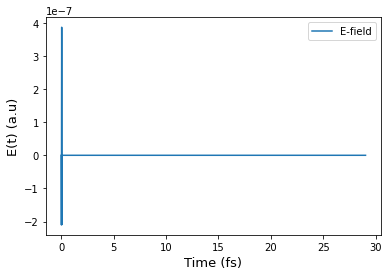

In [ ]:
plt.figure(2)
plt.plot(time*au2fs, field, label= 'E-field')
plt.xlabel(r"Time (fs)", size = 13)
plt.ylabel(r"E(t) (a.u)", size = 13)
plt.legend()
plt.show()

# Fourier transform of Current and Electric field
$$
J(\omega)=\int_{T}^{+\infty} J(t) e^{i \omega t - \gamma t} d t \\
E(\omega)=\int_{-\infty}^{+\infty} E(t) e^{i \omega t -  \gamma t} d t
$$

# Energy Axis

In [ ]:
energy = np.linspace(0/h2ev, 20/h2ev, 300)

In [ ]:
def FT(time, pump_current,electric_field, energy):
    global time_dt
    sigOutNum = np.zeros(len(energy)).astype(np.complex128)
    sigOutDenom = np.zeros(len(energy)).astype(np.complex128)
    gamma = 0.5/h2ev  #-np.log(1e-3)/time[-1]
    mask = np.exp(-gamma * time)

    current_tmp = pump_current * mask
    ef_tmp = electric_field * mask

    for ei, ee in enumerate(energy):
        sigOutNum[ei] = np.sum(np.exp(1j * ee * time) * current_tmp) * time_dt
        sigOutDenom[ei] = np.sum(np.exp(1j * ee * time) * ef_tmp) * time_dt

    return sigOutNum, sigOutDenom

Current, Laser = FT(time, pump_current, field, energy)

# Evaluate the Equillibrium optical conductivity
\begin{equation}
\sigma(\omega)=\frac{{J(ω)}}{E({\omega})}
\end{equation}

In [ ]:
equillibrium_sigma = Current / Laser

#Plot of Fourier Transform of Laser

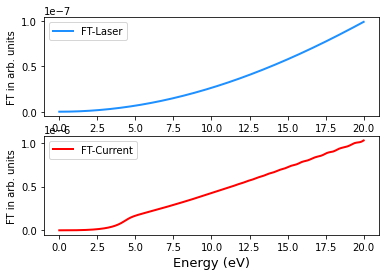

In [ ]:
plt.figure(3)
plt.subplot(2, 1, 1)
plt.plot(energy * h2ev, np.abs((Laser)), label="FT-Laser", color='dodgerblue', linewidth = 2)
plt.ylabel('FT in arb. units')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(energy * h2ev, np.abs((Current)), label="FT-Current", color='red', linewidth = 2)
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel('FT in arb. units')
plt.legend()
plt.show()

# Plot of Optical conductivity




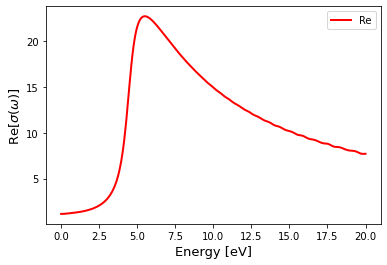

In [ ]:
plt.figure(4)
plt.plot(energy * h2ev, -1.0 * np.real(equillibrium_sigma), linestyle="-", label="Re", color='red', linewidth = 2)
plt.legend()
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$]", size = 13)
plt.show()

# Load Pump-probe data file

In [ ]:
pumpprobe = np.loadtxt("pumpprobe_zerodelay")
pumpprobe_time =  pumpprobe[:, 0]
pumpprobe_vecpot = pumpprobe[:, 1]                  #Current and vector potential for Pumpprobe calculation
pumpprobe_current = pumpprobe[:, 4]                 #pump current only
pumpprobe_efield = pumpprobe[:, 7]

# Plot of Pumprobe and Pump probe Current

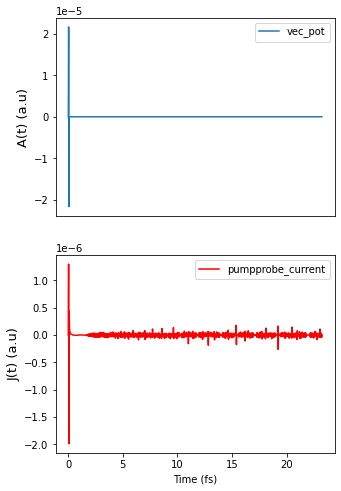

In [ ]:
fx = plt.figure()
fx.set_figwidth(5)
fx.set_figheight(8)
plt.figure(1)
plt.subplot(2,1,1)
plt.plot(pumpprobe_time*au2fs, pumpprobe_vecpot, label = 'vec_pot' )
plt.ylabel(r'A(t) (a.u)', size = 13)
plt.xticks([])
plt.legend()
plt.subplot(2,1,2)
plt.plot(pumpprobe_time*au2fs, pumpprobe_current, 'r', label = 'pumpprobe_current')
plt.ylabel(r'J(t) (a.u)', size = 13)
plt.xlabel(r'Time (fs)')
plt.legend()
plt.show()

# Evaluate the Pumpprobe Electric field

In [ ]:
pumpprobe_time_dt =  pumpprobe_time[1] - pumpprobe_time[0]
pumpprobe_field = -(1.0/c)*np.gradient(pumpprobe_vecpot, pumpprobe_time_dt)

# Plot of Pumpprobe Electric field

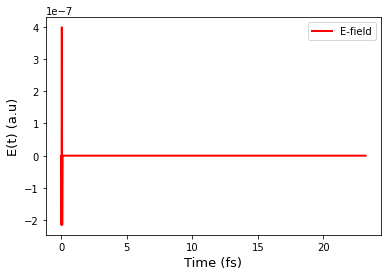

In [ ]:
plt.figure(2)
plt.plot(pumpprobe_time*au2fs, pumpprobe_field, 'r', label= 'E-field', linewidth =  2)
plt.xlabel(r"Time (fs)", size = 13)
plt.ylabel(r"E(t) (a.u)", size = 13)
plt.legend()
plt.show()

# Computing the Transient Optical Conductivity.
\begin{equation}
\vec{J}_{\text {probe }}(t):=\vec{J}_{\text {pump probe }}(t)- \vec{J}_{\text {pump }}(t)
\end{equation}

In [ ]:
probe_current = pumpprobe_current - pump_current.shape

# Plot the Probe Current

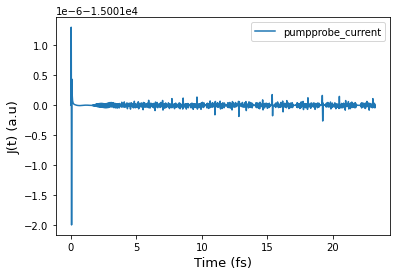

In [ ]:
plt.figure(3)
plt.plot(pumpprobe_time*au2fs, probe_current, label= 'pumpprobe_current')
plt.xlabel(r"Time (fs)", size = 13)
plt.ylabel(r"J(t) (a.u)", size = 13)
plt.legend()
plt.show()

# Fourier Transform of Pumpprobe Current

In [ ]:
def FT(pumpprobe_time, probe_current,pumpprobe_efield, energy):
    global pumpprobe_time_dt
    sigOutNum = np.zeros(len(energy)).astype(np.complex128)
    sigOutDenom = np.zeros(len(energy)).astype(np.complex128)
    gamma = 0.5/h2ev  #-np.log(1e-3)/time[-1]
    mask = np.exp(-gamma * pumpprobe_time)

    ppcurrent_tmp = pumpprobe_current * mask
    ppef_tmp = pumpprobe_efield * mask

    for ei, ee in enumerate(energy):
        sigOutNum[ei] = np.sum(np.exp(1j * ee * pumpprobe_time) * ppcurrent_tmp) * pumpprobe_time_dt
        sigOutDenom[ei] = np.sum(np.exp(1j * ee * pumpprobe_time) * ppef_tmp) * pumpprobe_time_dt

    return sigOutNum, sigOutDenom

aCurrent, aLaser = FT(pumpprobe_time, pumpprobe_current, pumpprobe_field, energy)

# Plot of Fourier Transform for pump probe and pump probe Current

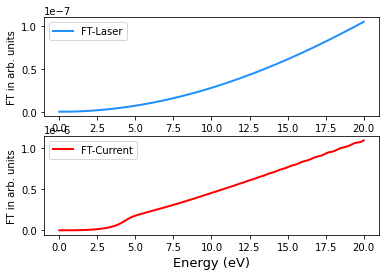

In [ ]:
plt.figure(4)
plt.subplot(2, 1, 1)
plt.plot(energy * h2ev, np.abs((aLaser)), label="FT-Laser", color='dodgerblue', linewidth = 2)
plt.ylabel('FT in arb. units')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(energy * h2ev, np.abs((aCurrent)), label="FT-Current", color='red', linewidth = 2)
plt.xlabel('Energy (eV)', size = 13)
plt.ylabel('FT in arb. units')
plt.legend()
plt.show()

# Compute Transient Optical Conductivity

In [ ]:
transient_sigma = aCurrent / aLaser

# Plot of Transient Conductivity

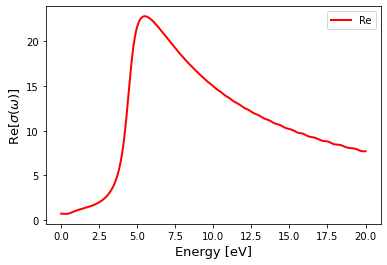

In [ ]:
plt.figure(5)
plt.plot(energy * h2ev, -1.0 * np.real(transient_sigma), linestyle="-", label="Re", color='red', linewidth = 2)
plt.legend()
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$]", size = 13)
plt.show()

# Plot of Linear response and Transient Optical Conductivity

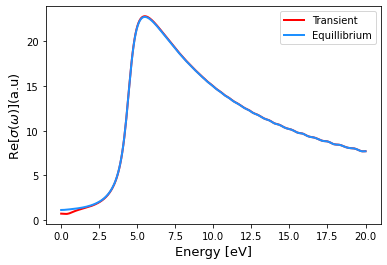

In [ ]:
plt.figure(6)
plt.plot(energy * h2ev, -1.0 * np.real(transient_sigma), linestyle="-", label="Transient", color='red', linewidth = 2)
plt.plot(energy * h2ev, -1.0 * np.real(equillibrium_sigma), linestyle="-", label="Equillibrium", color='dodgerblue', linewidth = 2)
plt.legend()
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$](a.u)", size = 13)
plt.savefig('Re_Conductivity_hBN.png', dpi = 1500)
plt.show()

# Difference between the equillibrium and Transient optical conductivity

In [ ]:
sigma_difference = transient_sigma - equillibrium_sigma

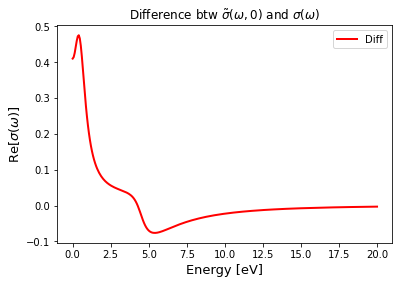

In [ ]:
plt.figure(7)
plt.plot(energy * h2ev, 1.0 * np.real(sigma_difference), linestyle="-", label="Diff", color='red', linewidth = 2)
plt.legend()
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\sigma(\omega)$]", size = 13)
plt.title(r'Difference btw $\tilde{\sigma}(\omega, 0)$ and $\sigma(\omega)$ ')
plt.show()


# Calculate the Transient Absorption Spectrum.

In [ ]:
trans = np.loadtxt("transient_absorption")                # Vector potential and Current file for pumpprobe only calculation
trans_time = trans[:, 0]                                 # Time steps
trans_vecpot =trans[:, 1]                               # Pump/probe field
trans_current = trans[:, 4]                             # Current
trans_efield = trans[:, 7]

# Split the data into chunks of 15001 lines

In [ ]:
num_lines = 15000
num_chunks = int(trans.shape[0] / num_lines)
trans_chunks = np.array_split(trans, num_chunks)

# plot each chunk of data

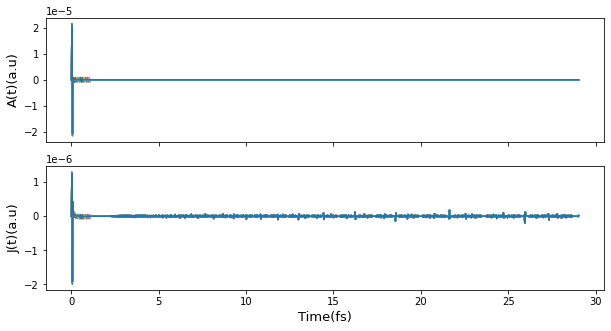

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for datachunk in trans_chunks:
    axs[0].plot(datachunk[:,0]*au2fs, datachunk[:,1])
    #axs[0].set_xlabel("Time(a.u)", size = 13)
    axs[0].set_ylabel(r"A(t)(a.u)", size = 13)
    #axs[0].legend()

for datachunk in trans_chunks:
    axs[1].plot(datachunk[:,0]*au2fs, datachunk[:,4])
    axs[1].set_xlabel("Time(fs)", size = 13)
    axs[1].set_ylabel(r"J(t)(a.u)", size = 13)

plt.show()

# Calculate the derivative of the sets of data

In [ ]:
trans_efield = []  #empty list to collect the results of the derivative

In [ ]:
for chunk in trans_chunks:
    # calculate the derivative of the second column
    dA_dt = np.gradient(chunk[:,1], chunk[:,0])
    # multiply the derivative by -1/c to get the final result
    c = 137.0
    efield = -1/c * dA_dt
    # add the result to the list
    trans_efield.append(efield)

In [ ]:
efield = np.concatenate(trans_efield)  #electric field of the data set

In [ ]:
trans_efield_portions= np.array_split(efield, len(efield)//15001)    #Split E-field into chunks of 15001 lines

# Plot the E-field

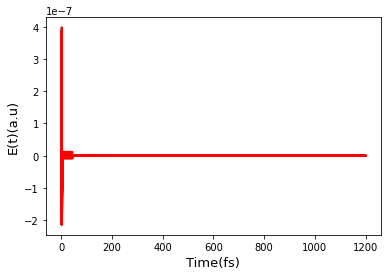

In [ ]:
plt.figure(12)
plt.plot(trans[:,0], efield, 'r', linewidth = 2.0)
plt.xlabel("Time(fs)", size = 13)
plt.ylabel(r"E(t)(a.u)", size = 13)
plt.show()

# Split trans_current into chunks of 15001 lines

In [ ]:
trans_current_portions = np.array_split(trans_current, len(trans_current)//15001)

# Subtract the Transient Currents from that of Equillibrium

In [ ]:
transprobe_current = [trans_current_portions[i] - pump_current for i in range(len(trans_current_portions))]

In [ ]:
len(trans_current_portions[0]), len(transprobe_current)

(15001, 11)

# Plot of Transient Probe Current

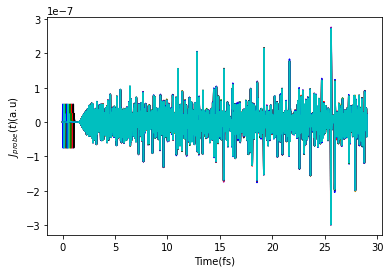

In [ ]:
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

plt.figure()
# iterate over the chunks
for i, portions in enumerate(transprobe_current):
    plt.plot(trans[i*15001:i*15001+15001,0]*au2fs, portions, color=colors[i%len(colors)])

plt.xlabel(r"Time(fs)")
plt.ylabel(r"$J_{probe}(t)$(a.u)")
plt.show()

# Calculate the Fourier Transform of the data set

# Energy and Time axis

In [ ]:
trans_energy  = np.linspace(0/h2ev, 20/h2ev, 300)
transprobe_time_portions = np.array_split(trans_time, len(trans_time)//15001)
trans_time_dt = trans_time[1] - trans_time[0]

In [ ]:
def FT(transprobe_time_portions, transprobe_current, trans_efield_portions, trans_energy):
    global trans_time_dt
    sigOutNum = []
    sigOutDenom = []

    gamma = 0.5/27.2114

    tt = np.array(transprobe_time_portions[0][:])
    transprobe_current = np.array(transprobe_current)
    trans_efield_portions = np.array(trans_efield_portions)
    mask = np.exp(-gamma * tt)
    ppcurrent_tmp = transprobe_current *mask
    ppef_tmp = trans_efield_portions *mask
    ee = trans_energy

    FTmat=np.exp(1j*ee[None,:]*tt[:,None])

    sigOutNum = np.sum((FTmat)[None,:,:]*ppcurrent_tmp[:,:,None], axis=1)* trans_time_dt
    sigOutDenom = np.sum((FTmat)[None,:,:]*ppef_tmp[:,:,None], axis=1)* trans_time_dt
    # print((FTmat)[None,:,:]*ppcurrent_tmp[:,:,None]).shape)

    return sigOutNum, sigOutDenom

tas_current, tas_laser =  FT(transprobe_time_portions, transprobe_current, trans_efield_portions, trans_energy)

# Plot of the FT of Laser and Current

<Figure size 432x288 with 0 Axes>

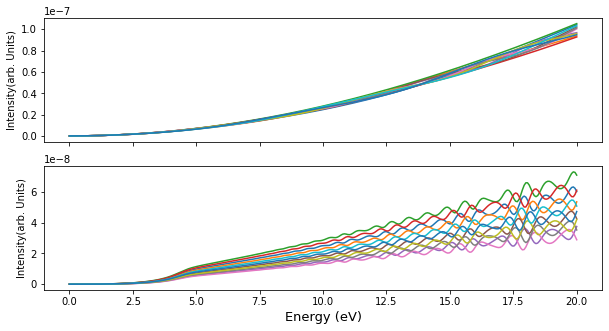

In [ ]:
plt.figure()
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axs[0].plot(np.multiply(trans_energy, h2ev), np.abs((tas_laser)).T,)
axs[0].set_ylabel('Intensity(arb. Units)')
axs[1].plot(np.multiply(trans_energy, h2ev), np.abs((tas_current)).T,)
axs[1].set_xlabel('Energy (eV)', size = 13)
axs[1].set_ylabel('Intensity(arb. Units)')
plt.show()

# Take the ratio of current to laser
\begin{equation}
\tilde{\sigma}(\omega, T)=\frac{{J(ω)}}{E({\omega})}
\end{equation}

In [ ]:
tas_sigma =  (tas_current/tas_laser).T

# Plot of tas_sigma

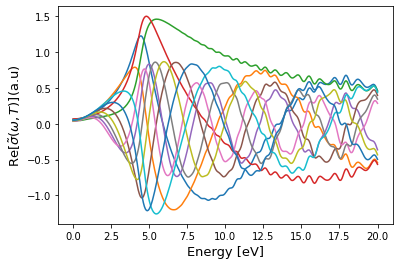

In [ ]:
plt.plot(trans_energy*h2ev, -1.0*(np.real(tas_sigma)))
plt.xlabel("Energy [eV]", size = 13)
plt.ylabel(r"Re[$\tilde{\sigma}(\omega, T)$](a.u)", size = 13)
plt.show()

 # Subtract the tas_sigma from the equillibrium sigma to obtain tas

In [ ]:
trans_diff = np.subtract(tas_sigma, equillibrium_sigma.reshape(-1, 1))

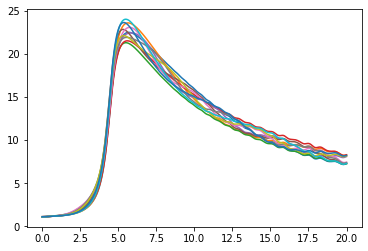

In [ ]:
plt.plot(trans_energy*h2ev, 1.0*np.real(trans_diff))
plt.show()

#Density plot to obtain the TAS!!


Text(0, 0.5, 'Energy (eV)')

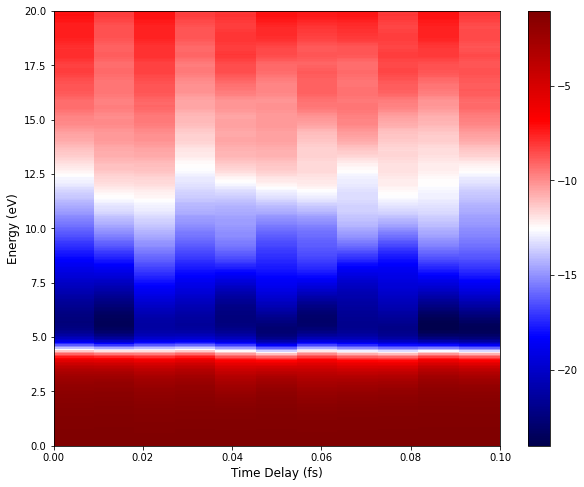

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
#vmin = 5
#vmax = 5
X, Y = np.meshgrid(np.linspace(0, 0.1, 12), np.linspace(min(trans_energy*h2ev), max(trans_energy*h2ev), 300))
#fig, ax = plt.subplots()
pos = ax.pcolormesh(X, Y, -1.0*np.real(trans_diff), cmap='seismic')
fig.colorbar(pos, ax=ax)
plt.xlabel('Time Delay (fs)', size = 12)
plt.ylabel('Energy (eV)', size = 12)

Text(0, 0.5, 'Energy (eV)')

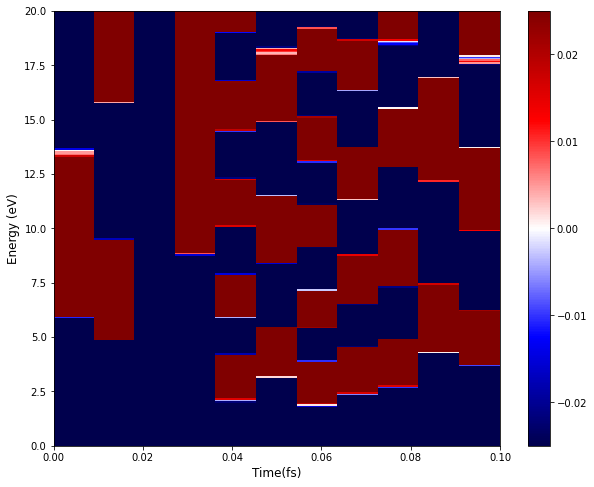

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
vmin =-0.025 #-1.0*np.max(np.abs(trans_diff))
vmax = 0.025 #1.0* np.max(np.abs(trans_diff))
#fig, ax = plt.subplots(1,1,1)
pos = ax.pcolormesh(X, Y, 1.0*np.real(tas_sigma), cmap='seismic', vmin=vmin, vmax=vmax)
fig.colorbar(pos, ax=ax)
plt.xlabel('Time(fs)', size = 12)
plt.ylabel('Energy (eV)', size = 12)

#Reference
https://www.mdpi.com/2076-3417/8/10/1777